# Biomarcadores transcriptómicos intestinales asociados a la eficiencia digestiva en dorada y lubina
## Trabajo Fin de Máster — Máster Universitario en Bioinformática
### Universidad de Murcia | Autor: Ángel López Francés

---

Este notebook documenta el pipeline bioinformático completo utilizado para:
1. Preparar las matrices de counts a partir de datos públicos de GEO
2. Realizar el análisis de expresión diferencial
3. Identificar biomarcadores transcriptómicos en intestino de dorada (*Sparus aurata*) y lubina (*Dicentrarchus labrax*)

**Datasets utilizados:**
- **Dorada:** GSE194206 — Firmino et al. (2022), *Frontiers in Marine Science*. RNA-seq Illumina NextSeq500. Intestino anterior-medio, 5 Control vs 5 SDY_diet.
- **Lubina:** GSE59240 — Calduch-Giner et al. (2016), *Frontiers in Physiology*. Microarray Agilent 8×15K. Intestino anterior, medio y posterior.

**Herramientas:** Python 3, pandas, numpy, matplotlib, seaborn, pydeseq2, scipy

## 1. Instalación de dependencias

Ejecutar solo la primera vez en el caso de no tener instalados los paquetes

In [1]:
# Instalar librerías necesarias
!pip install pandas numpy matplotlib seaborn pydeseq2 scipy scikit-learn

   ---------------------------------------- 0.0/801.4 kB ? eta -:--:--
   ---------------------------------------- 801.4/801.4 kB 17.4 MB/s  0:00:00

   -- -------------------------------------  1/17 [session-info2]
   -- -------------------------------------  1/17 [session-info2]
   -- -------------------------------------  1/17 [session-info2]
   -- -------------------------------------  1/17 [session-info2]
   ---- -----------------------------------  2/17 [numcodecs]
   ---- -----------------------------------  2/17 [numcodecs]
   ---- -----------------------------------  2/17 [numcodecs]
   ---- -----------------------------------  2/17 [numcodecs]
   ---- -----------------------------------  2/17 [numcodecs]
   ---- -----------------------------------  2/17 [numcodecs]
   ---- -----------------------------------  2/17 [numcodecs]
   ---- -----------------------------------  2/17 [numcodecs]
   ---- -----------------------------------  2/17 [numcodecs]
   ---- --------------------

## 2. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

print('Librerías importadas')

Librerías importadas


## 3. Carga y preparación de datos — Dorada (*Sparus aurata*)

### 3.1 Descripción del dataset

Los archivos de counts individuales se descargaron del repositorio NCBI GEO (accession **GSE194206**).
Cada archivo corresponde a una muestra y fue generado con `featureCounts v1.5.3` mapeando contra el genoma de referencia *Sparus aurata* (GCF_900880675.1).

**Estructura de grupos:**
- `intd1` (n=5): muestras de intestino del grupo Control (dieta estándar con harina de pescado)
- `intd2` (n=5): muestras de intestino del grupo SDY (dieta con 30% de levadura de cerveza seca)

### 3.2 Fusión de archivos de counts individuales en una matriz

In [ ]:
# Creamos un diccionario que contiene cada nombre de muestra con su ruta al archivo de counts

archivos_dorada = {
    'intd1_1': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830854_intd1_1_counts.txt',
    'intd1_2': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830855_intd1_2_counts.txt',
    'intd1_4': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830856_intd1_4_counts.txt',
    'intd1_5': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830857_intd1_5_counts.txt',
    'intd1_6': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830858_intd1_6_counts.txt',
    'intd2_8': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830863_intd2_8_counts.txt',
    'intd2_10': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830859_intd2_10_counts.txt',
    'intd2_11': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830860_intd2_11_counts.txt',
    'intd2_12': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830861_intd2_12_counts.txt',
    'intd2_13': 'c:\\Users\\angel\\Desktop\\datos tfm\\datos dorada\\GSM5830862_intd2_13_counts.txt',
}

# Fusionar todos los archivos en una sola matriz de counts
dfs = []
for muestra, ruta in archivos_dorada.items():
    df = pd.read_csv(ruta, sep='\t', comment='#') 
    columna_counts = df.columns[-1]                 
    df = df[['Geneid', columna_counts]].rename(columns={columna_counts: muestra})
    dfs.append(df)

# Merge progresivo por Geneid
counts_dorada = dfs[0]
for df in dfs[1:]:
    counts_dorada = counts_dorada.merge(df, on='Geneid')

counts_dorada = counts_dorada.set_index('Geneid')

print(f'Dimensiones de la matriz: {counts_dorada.shape[0]} genes x {counts_dorada.shape[1]} muestras')
print(f'\nPrimeras filas:')
counts_dorada.head()

Dimensiones de la matriz: 25722 genes x 10 muestras

Primeras filas:


,intd1_1,intd1_2,intd1_4,intd1_5,intd1_6,intd2_8,intd2_10,intd2_11,intd2_12,intd2_13
Geneid,,,,,,,,,,
LOC115578356,1832,1109,2337,1631,1920,1753,1175,1625,1831,1168
LOC115578906,7,0,2,3,4,2,7,3,6,5
LOC115572434,1,1,0,0,0,0,0,0,0,1
LOC115592056,100,75,83,121,100,59,84,86,66,91
gemin6,33,41,83,348,44,87,145,63,68,145


### 3.3 Control de calidad — distribución de counts

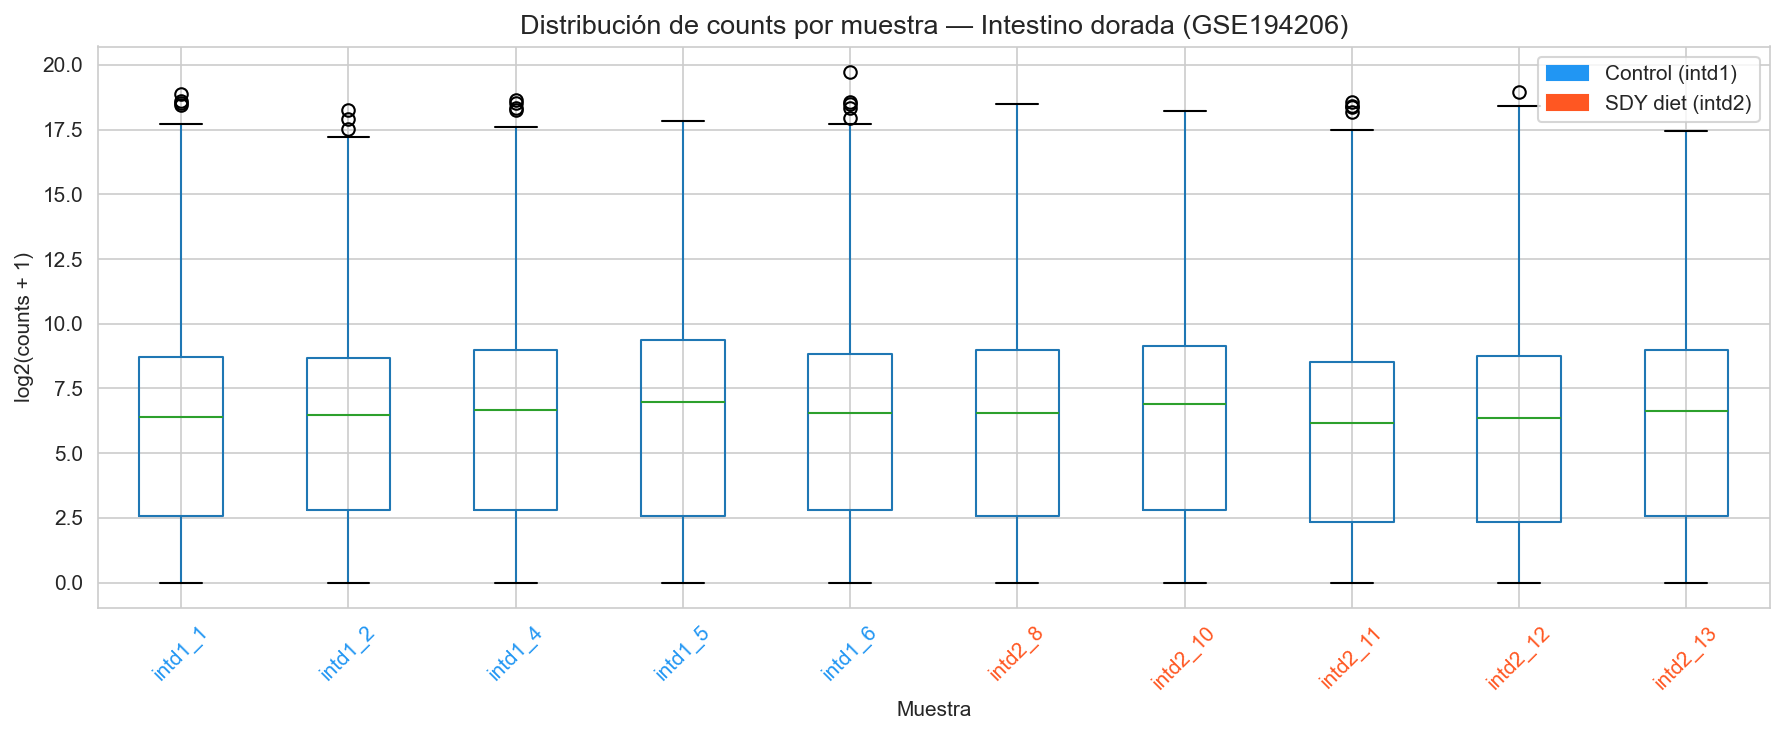

Figura guardada: QC_boxplot_dorada.png


In [ ]:
# Generamos un boxplot de distribución de counts por muestra (escala log2)
fig, ax = plt.subplots(figsize=(12, 5))

log_counts = np.log2(counts_dorada + 1)  # +1 para evitar log(0)
log_counts.boxplot(ax=ax, rot=45)

ax.set_title('Distribución de counts por muestra — Intestino dorada (GSE194206)', fontsize=13)
ax.set_ylabel('log2(counts + 1)')
ax.set_xlabel('Muestra')

# Colorear por grupo
for i, tick in enumerate(ax.get_xticklabels()):
    color = '#2196F3' if i < 5 else '#FF5722'  # azul=Control, naranja=SDY
    tick.set_color(color)

legend_elements = [
    mpatches.Patch(color='#2196F3', label='Control (intd1)'),
    mpatches.Patch(color='#FF5722', label='SDY diet (intd2)')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('QC_boxplot_dorada.png', bbox_inches='tight')
plt.show()
print('Figura guardada')

### 3.4 Filtrado de genes de baja expresión

Se eliminan genes con counts muy bajos que no aportan información estadística fiable.
Criterio estándar: mínimo 10 counts en al menos 2 muestras.

In [ ]:
min_counts = 10
min_muestras = 2

mascara = (counts_dorada >= min_counts).sum(axis=1) >= min_muestras
counts_filtrado = counts_dorada[mascara]

print(f'Genes antes del filtrado:  {counts_dorada.shape[0]:,}')
print(f'Genes después del filtrado: {counts_filtrado.shape[0]:,}')
print(f'Genes eliminados: {counts_dorada.shape[0] - counts_filtrado.shape[0]:,}')

Genes antes del filtrado:  25,722
Genes después del filtrado: 19,494
Genes eliminados: 6,228


### 3.5 Normalización CPM (Counts Per Million)

La normalización CPM corrige las diferencias en profundidad de secuenciación entre muestras.

In [8]:
# Normalización CPM
totales = counts_filtrado.sum(axis=0)  # total de counts por muestra
cpm = counts_filtrado.divide(totales, axis=1) * 1e6
log2_cpm = np.log2(cpm + 1)

print('Totales de counts por muestra (profundidad de secuenciación):')
for muestra, total in totales.items():
    print(f'  {muestra}: {total:,}')

Totales de counts por muestra (profundidad de secuenciación):
  intd1_1: 17,810,089
  intd1_2: 15,550,645
  intd1_4: 19,794,468
  intd1_5: 20,571,517
  intd1_6: 20,076,342
  intd2_8: 19,162,001
  intd2_10: 19,323,802
  intd2_11: 16,961,679
  intd2_12: 17,795,337
  intd2_13: 17,371,699


## 4. Análisis de Componentes Principales (PCA)

El PCA permite visualizar si las muestras se agrupan correctamente según su grupo experimental, validando la calidad del experimento.

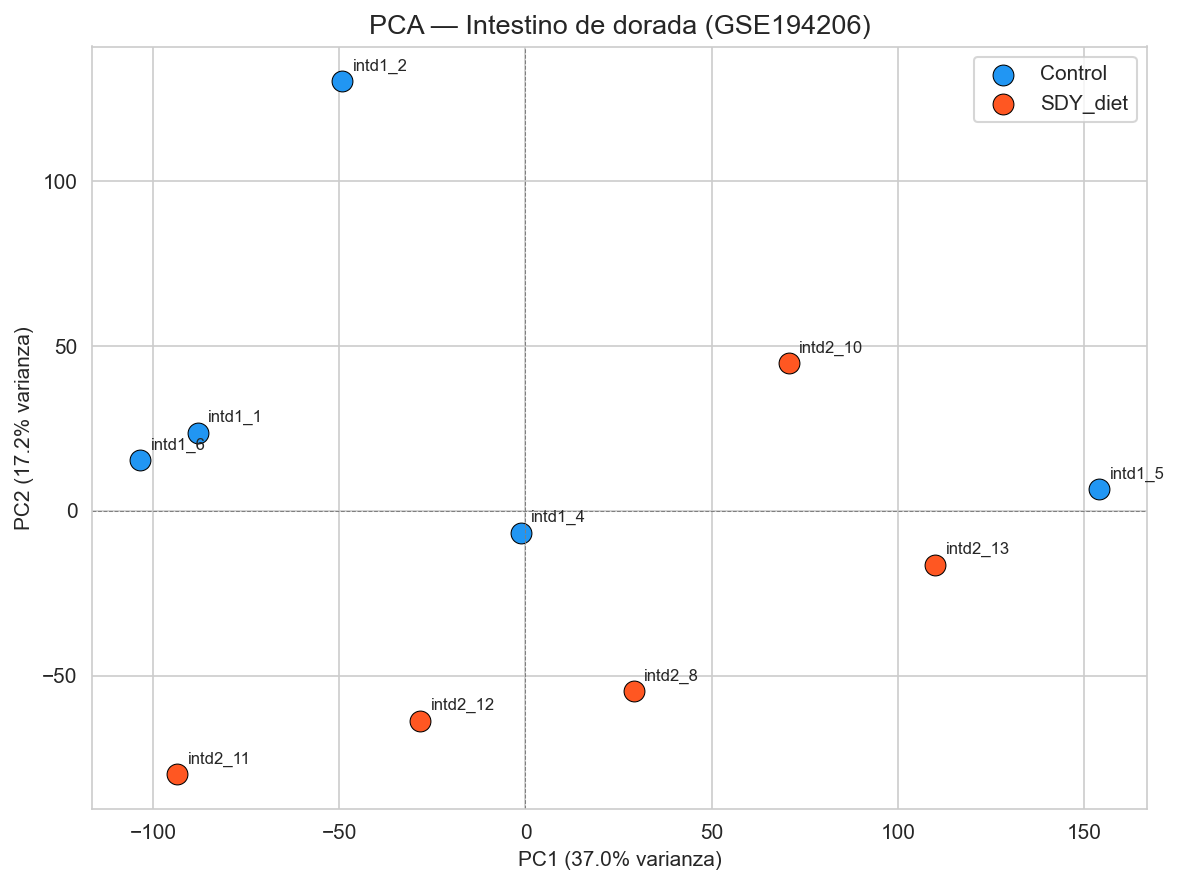

Figura guardada: PCA_dorada.png


In [ ]:
# PCA sobre los datos normalizados
X = log2_cpm.T  
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)
varianza = pca.explained_variance_ratio_ * 100

# Crear dataframe para el plot
df_pca = pd.DataFrame(componentes, columns=['PC1', 'PC2'],
                      index=log2_cpm.columns)
df_pca['Grupo'] = ['Control'] * 5 + ['SDY_diet'] * 5

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
colores = {'Control': '#2196F3', 'SDY_diet': '#FF5722'}

for grupo, datos in df_pca.groupby('Grupo'):
    ax.scatter(datos['PC1'], datos['PC2'],
               label=grupo, color=colores[grupo],
               s=100, edgecolors='black', linewidth=0.5)
    for idx, row in datos.iterrows():
        ax.annotate(idx, (row['PC1'], row['PC2']),
                    textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.set_xlabel(f'PC1 ({varianza[0]:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({varianza[1]:.1f}% varianza)')
ax.set_title('PCA — Intestino de dorada (GSE194206)', fontsize=13)
ax.legend()
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('PCA_dorada.png', bbox_inches='tight')
plt.show()
print('Figura guardada: PCA_dorada.png')

## 5. Análisis de Expresión Diferencial con PyDESeq2

DESeq2 es el método estándar para análisis de expresión diferencial en RNA-seq.
Compara el grupo SDY_diet vs Control para identificar genes significativamente regulados.

**Criterios de significancia:**
- FDR (p-valor ajustado) < 0.05
- |log2 Fold Change| > 1 (equivalente a FC > 2)

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# Preparar metadatos
metadata = pd.DataFrame({
    'condition': ['Control'] * 5 + ['SDY_diet'] * 5
}, index=counts_filtrado.columns)

# Crear objeto DESeq2
dds = DeseqDataSet(
    counts=counts_filtrado.T,  
    metadata=metadata,
    design_factors='condition',
    refit_cooks=True,
)

# Ajustar el modelo
dds.deseq2()
print('Modelo DESeq2 ajustado')

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.57 seconds.

Fitting dispersion trend curve...
... done in 0.36 seconds.

Fitting MAP dispersions...
... done in 2.02 seconds.

Fitting LFCs...


Modelo DESeq2 ajustado


... done in 1.28 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [ ]:
# Calcular estadísticos: SDY_diet vs Control
stats_res = DeseqStats(dds, contrast=['condition', 'SDY_diet', 'Control'])
stats_res.summary()


resultados = stats_res.results_df

# Filtrar genes significativos
DEGs = resultados[
    (resultados['padj'] < 0.05) &
    (resultados['log2FoldChange'].abs() > 1)
].copy()

DEGs_up = DEGs[DEGs['log2FoldChange'] > 0]
DEGs_down = DEGs[DEGs['log2FoldChange'] < 0]

print(f'\n Resultados DESeq2 (SDY_diet vs Control):')
print(f'   Total genes analizados: {len(resultados):,}')
print(f'   Genes DEG totales (FDR<0.05, |FC|>2): {len(DEGs):,}')
print(f'   Genes up-regulados (SDY_diet): {len(DEGs_up):,}')
print(f'   Genes down-regulados (SDY_diet): {len(DEGs_down):,}')

Running Wald tests...


Log2 fold change & Wald test p-value: condition SDY_diet vs Control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Geneid                                                                    
LOC115578356  1655.582797       -0.114762  0.278007 -0.412801  0.679752   
LOC115592056    86.470988       -0.221274  0.218276 -1.013736  0.310709   
gemin6          97.567078        0.088574  0.548077  0.161609  0.871614   
LOC115585195   452.183968       -0.016206  0.112447 -0.144116  0.885408   
LOC115582062   309.778876        0.033180  0.120394  0.275597  0.782858   
...                   ...             ...       ...       ...       ...   
LOC115578260   170.215151       -0.091274  0.189462 -0.481751  0.629983   
LOC115578279    10.409605       -0.328812  0.431723 -0.761626  0.446283   
LOC115578285    30.949062        0.196927  0.279599  0.704318  0.481235   
LOC115578281    19.144073       -0.066860  0.391677 -0.170703  0.864457   
LOC115578256    18.511107       

... done in 0.83 seconds.



### 5.1 Volcano Plot

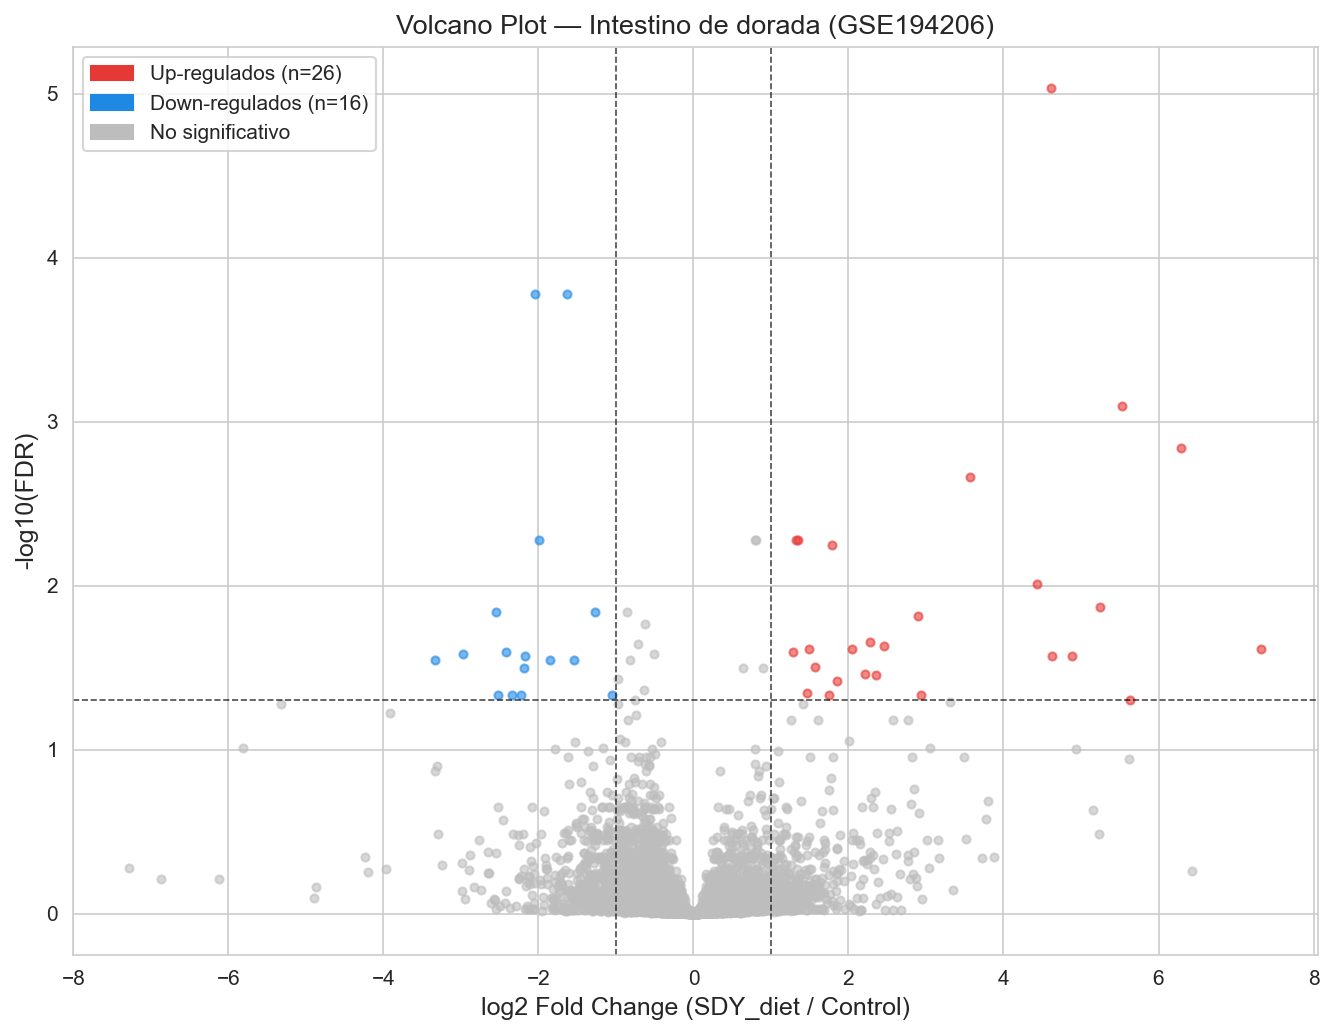

Figura guardada: VolcanoPlot_dorada.png


In [13]:
# Volcano plot
fig, ax = plt.subplots(figsize=(9, 7))

res = resultados.dropna(subset=['padj', 'log2FoldChange'])
res['-log10_padj'] = -np.log10(res['padj'])

# Clasificar genes
def clasificar(row):
    if row['padj'] < 0.05 and row['log2FoldChange'] > 1:
        return 'Up'
    elif row['padj'] < 0.05 and row['log2FoldChange'] < -1:
        return 'Down'
    return 'NS'

res['color'] = res.apply(clasificar, axis=1)
palette = {'Up': '#E53935', 'Down': '#1E88E5', 'NS': '#BDBDBD'}

for grupo, datos in res.groupby('color'):
    ax.scatter(datos['log2FoldChange'], datos['-log10_padj'],
               c=palette[grupo], s=15, alpha=0.6, label=grupo, rasterized=True)

# Líneas de corte
ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(-1, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_xlabel('log2 Fold Change (SDY_diet / Control)', fontsize=12)
ax.set_ylabel('-log10(FDR)', fontsize=12)
ax.set_title('Volcano Plot — Intestino de dorada (GSE194206)', fontsize=13)

# Leyenda con conteos
n_up = (res['color'] == 'Up').sum()
n_down = (res['color'] == 'Down').sum()
legend = [
    mpatches.Patch(color='#E53935', label=f'Up-regulados (n={n_up})'),
    mpatches.Patch(color='#1E88E5', label=f'Down-regulados (n={n_down})'),
    mpatches.Patch(color='#BDBDBD', label='No significativo'),
]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig('VolcanoPlot_dorada.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figura guardada: VolcanoPlot_dorada.png')

### 5.2 Heatmap de los top 50 genes DEG

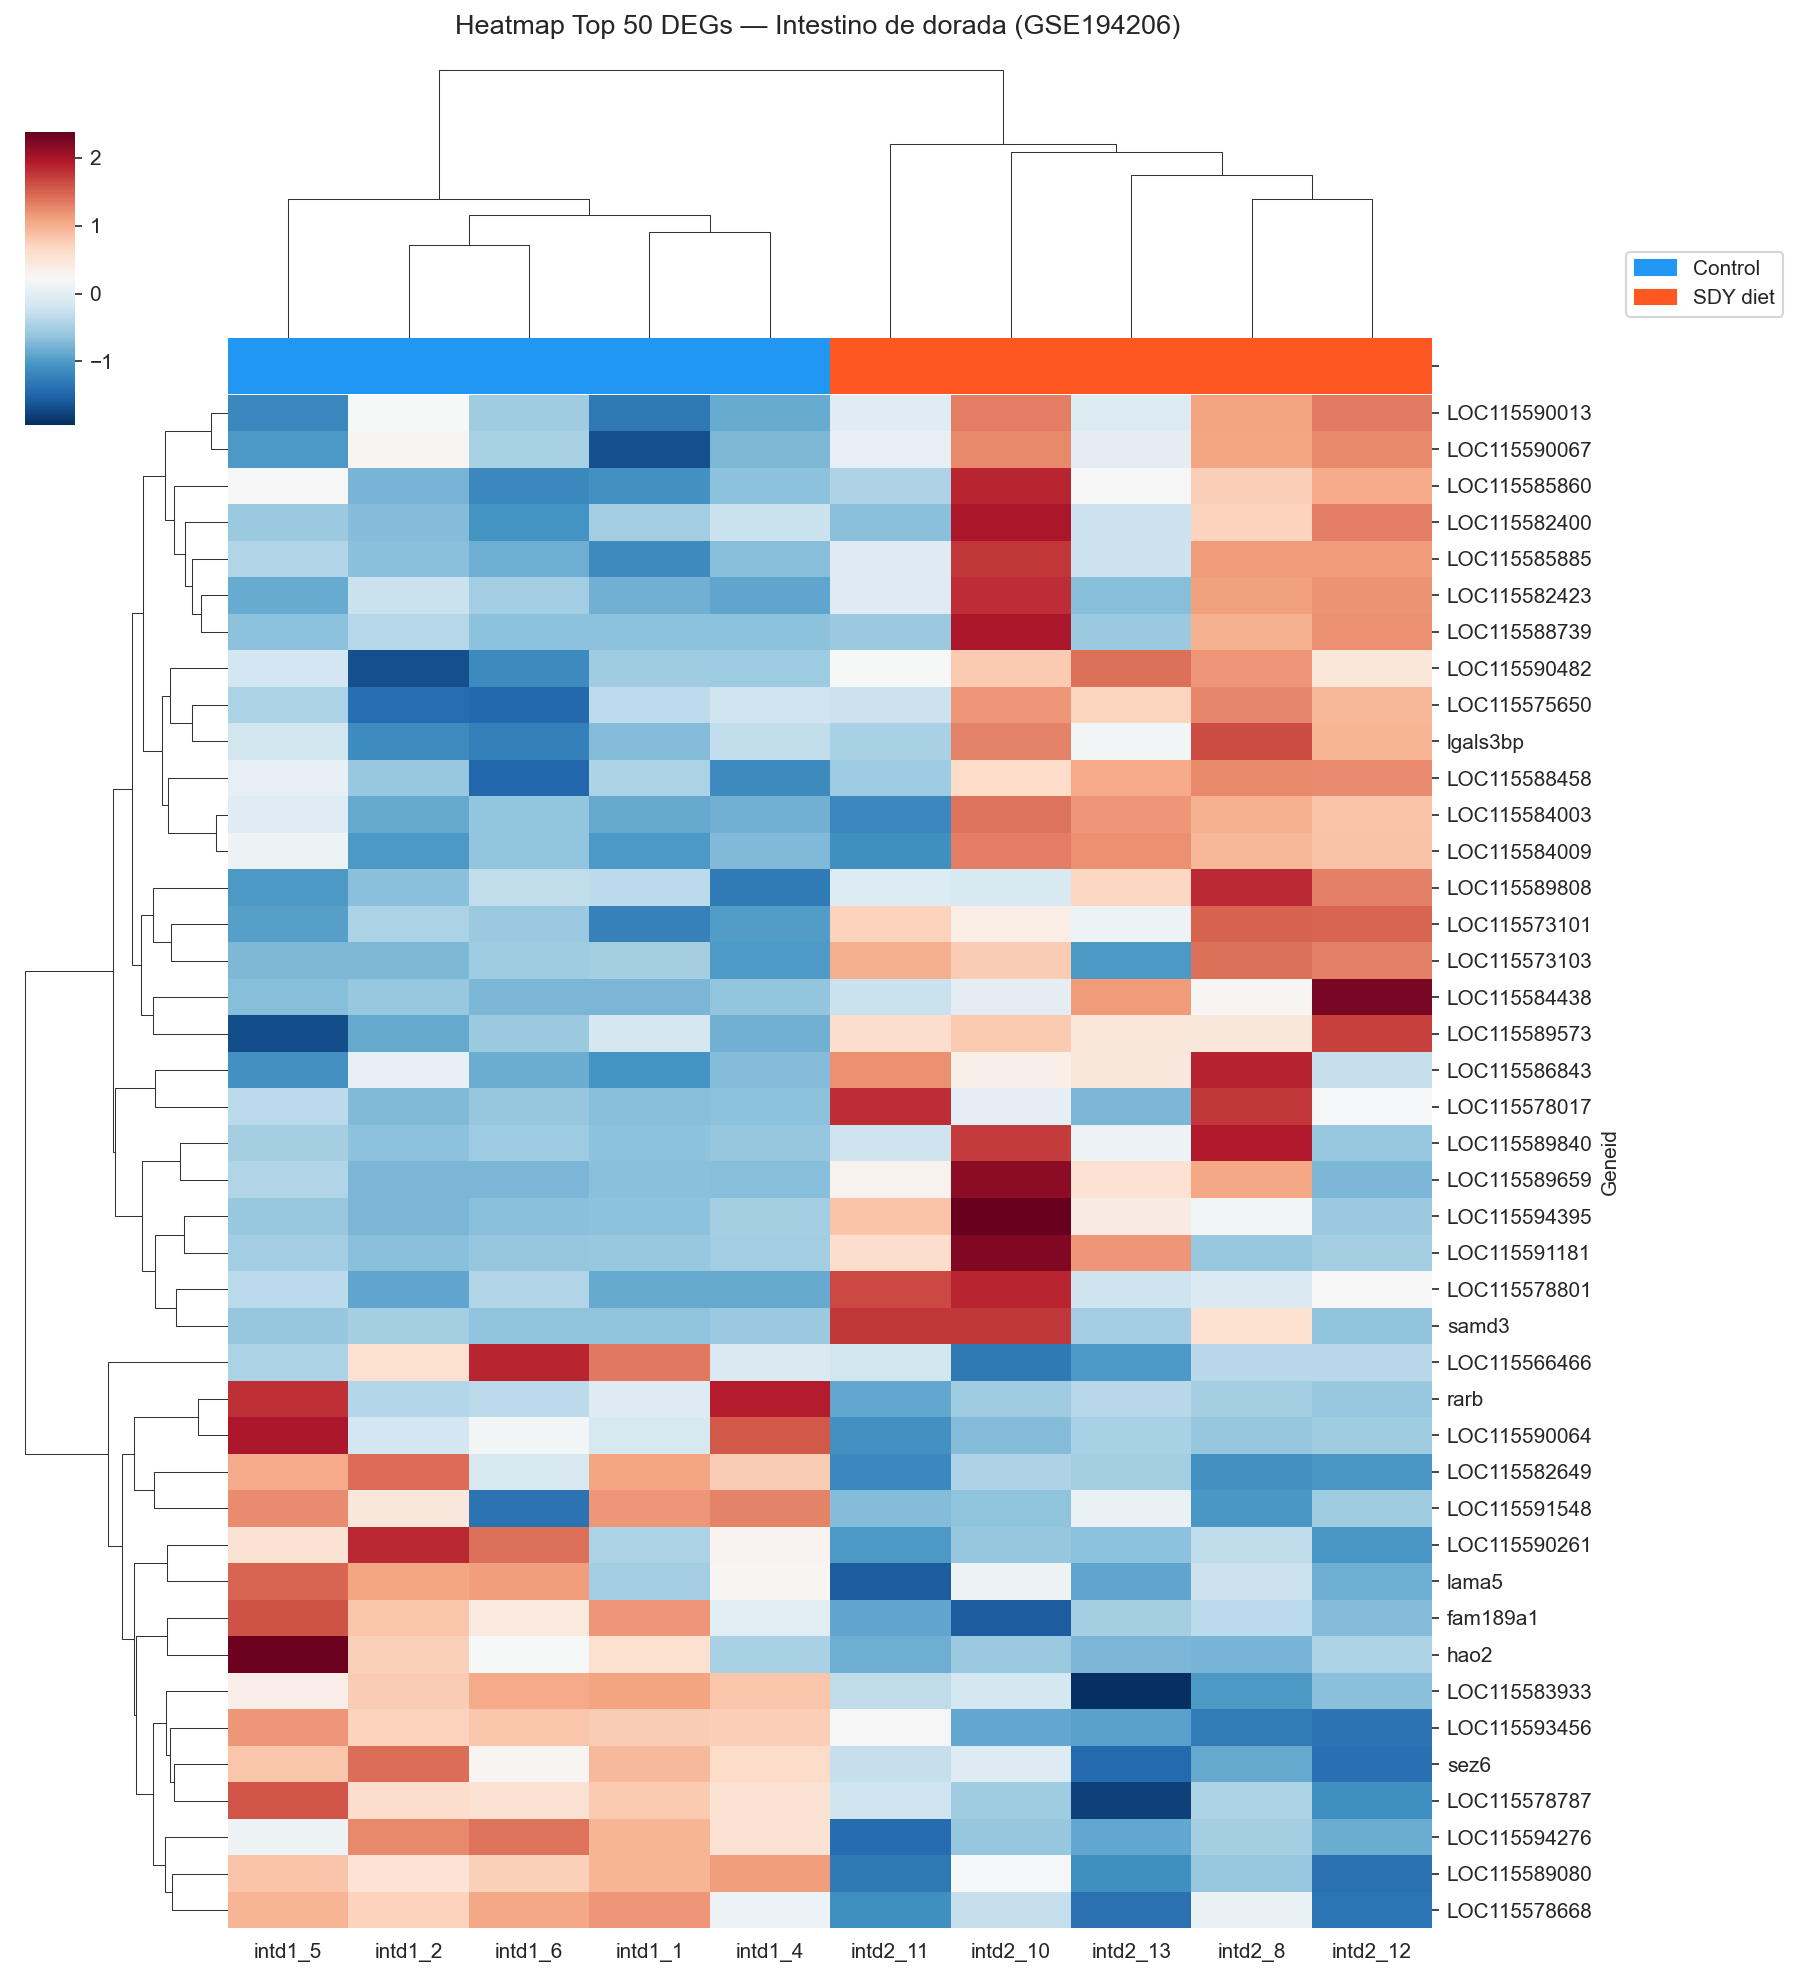

Figura guardada: Heatmap_dorada.png


In [ ]:
# Seleccionamos el top 50 DEGs por p-valor ajustado
top50 = DEGs.nsmallest(50, 'padj').index.tolist()
top50_disponibles = [g for g in top50 if g in log2_cpm.index]

heatmap_data = log2_cpm.loc[top50_disponibles]

# Asignamos colores por grupo para la barra superior
col_colors = pd.Series(
    ['#2196F3'] * 5 + ['#FF5722'] * 5,
    index=log2_cpm.columns
)

g = sns.clustermap(
    heatmap_data,
    col_colors=col_colors,
    cmap='RdBu_r',
    z_score=0,          
    figsize=(11, 13),
    dendrogram_ratio=0.15,
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    xticklabels=True,
    yticklabels=True,
)
g.fig.suptitle('Heatmap Top 50 DEGs — Intestino de dorada (GSE194206)',
               y=1.01, fontsize=13)

# Leyenda para los grupos
legend_elements = [
    mpatches.Patch(color='#2196F3', label='Control'),
    mpatches.Patch(color='#FF5722', label='SDY diet')
]
g.ax_heatmap.legend(handles=legend_elements, loc='upper right',
                    bbox_to_anchor=(1.3, 1.1))

plt.savefig('Heatmap_dorada.png', bbox_inches='tight', dpi=200)
plt.show()
print('Figura guardada: Heatmap_dorada.png')

### 5.3 Exportar lista de DEGs

In [16]:
# Guardar tabla completa de DEGs
DEGs_ordenados = DEGs.sort_values('padj')
DEGs_ordenados.to_csv('DEGs_dorada_intestino.csv')

# Mostrar top 20
print('Top 20 genes más significativos:')
print(DEGs_ordenados[['baseMean','log2FoldChange','pvalue','padj']].head(20).to_string())
print(f'\n Tabla guardada: DEGs_dorada_intestino.csv')

Top 20 genes más significativos:
                 baseMean  log2FoldChange        pvalue      padj
Geneid                                                           
LOC115585885   286.143558        4.606984  4.757902e-10  0.000009
LOC115582649    30.686657       -2.042192  1.730351e-08  0.000166
LOC115594276   136.026491       -1.631840  2.578039e-08  0.000166
LOC115584438    22.821618        5.526798  1.650977e-07  0.000799
LOC115589840    43.361199        6.294315  3.734767e-07  0.001447
LOC115578801   586.581932        3.564039  6.764763e-07  0.002184
fam189a1        77.418300       -1.994598  2.532805e-06  0.005290
LOC115590482    49.436454        1.321747  2.628347e-06  0.005290
LOC115573101   258.613462        1.353442  2.792527e-06  0.005290
LOC115575650   380.211944        1.790774  3.510408e-06  0.005666
LOC115594395    14.862448        4.433764  6.579825e-06  0.009802
LOC115582423   229.687188        5.247896  9.811126e-06  0.013572
hao2            63.139535       -2.554069  

## 6. Anotación funcional de los DEGs

Los genes en este dataset están identificados con IDs tipo `LOC115XXXXXX`.
Para anotarlos con nombres de genes y rutas KEGG, usamos **iDEP** (http://bioinformatics.sdstate.edu/idep/).



Los resultados de iDEP se interpretan en la sección de Resultados del TFM.

In [18]:
# Exportar matriz lista para iDEP
counts_filtrado.to_csv('dorada_intestine_counts.csv')
print(' Matriz exportada: dorada_intestine_counts.csv')
print(f'   Genes: {counts_filtrado.shape[0]:,}')
print(f'   Muestras: {counts_filtrado.shape[1]}')
print(f'   Grupos: Control (n=5) vs SDY_diet (n=5)')

 Matriz exportada: dorada_intestine_counts.csv
   Genes: 19,494
   Muestras: 10
   Grupos: Control (n=5) vs SDY_diet (n=5)


## 8. Resumen del pipeline

| Paso | Herramienta | Parámetros |
|------|-------------|------------|
| Descarga de datos | NCBI GEO | Accession GSE194206 |
| Fusión de archivos | pandas `read_csv` + `merge` | `comment='#'`, join por Geneid |
| Filtrado | pandas | ≥10 counts en ≥2 muestras |
| Normalización | CPM manual | log2(CPM+1) |
| PCA | scikit-learn | StandardScaler + PCA(n=2) |
| Expresión diferencial | PyDESeq2 | FDR<0.05, \|log2FC\|>1 |
| Visualización | matplotlib + seaborn | Volcano plot, Heatmap, PCA |
| Anotación funcional | iDEP | KEGG, Gene Ontology |

**Referencia del dataset:**
Firmino, J. P., et al. (2022). Brewer's spent dry yeast modulates immunity in gilthead sea bream (*Sparus aurata*). *Frontiers in Marine Science, 9*, 857592. https://doi.org/10.3389/fmars.2022.857592

NCBI GEO Accession: GSE194206

In [19]:
# Información de sesión
import sys
print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')

Python: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 12:58:53) [MSC v.1929 64 bit (AMD64)]
pandas: 2.3.3
numpy: 2.0.1
matplotlib: 3.10.6
seaborn: 0.13.2
